In [1]:
# ============================================================
# Cell 1 - Upload Dataset to Google Colab
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving Oil well.xlsx to Oil well.xlsx


In [2]:
# ============================================================
# Cell 2 - Import Libraries
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Fixed seed helps produce similar results each time
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("TensorFlow version:", tf.__version__)
print(
    "GPU available:",
    len(tf.config.list_physical_devices("GPU")) > 0
)

TensorFlow version: 2.20.0
GPU available: True


In [3]:
# ============================================================
# Cell 3 - Check Uploaded Files
# ============================================================

uploaded_files = list(uploaded.keys())

print("Uploaded files:")

for file_name in uploaded_files:
    print(file_name)

Uploaded files:
Oil well.xlsx


In [4]:
# ============================================================
# Cell 4 - Load Dataset
# ============================================================

FILE_PATH = uploaded_files[0]

df = pd.read_excel(
    FILE_PATH,
    skiprows=2
)

print("File used:", FILE_PATH)
print("Dataset shape:", df.shape)

display(df.head())

File used: Oil well.xlsx
Dataset shape: (2939, 9)


,Date,\nOil volume (m3/day),Volume of liquid (m3/day),\nGas volume (m3/day),Water volume (m3/day),Water cut (%),\nWorking hours,\nDynamic level (m),\nReservoir pressure (atm)
0,2013-01-01,49,70,13055,21,29,24,1819,214
1,2013-01-02,49,70,13055,21,29,24,1836,214
2,2013-01-03,49,70,13055,21,29,24,1788,214
3,2013-01-04,49,70,13055,21,29,24,1789,214
4,2013-01-05,44,70,11768,26,36,24,1825,214


In [5]:
# ============================================================
# Cell 5 - Inspect Dataset
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")

for index, column in enumerate(df.columns):
    print(index, ":", repr(column))

print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())

Number of rows: 2939
Number of columns: 9

Column names:
0 : 'Date'
1 : '\nOil volume (m3/day)'
2 : 'Volume of liquid (m3/day)'
3 : '\nGas volume (m3/day)'
4 : 'Water volume (m3/day)'
5 : 'Water cut (%) '
6 : '\nWorking hours'
7 : '\nDynamic level (m)'
8 : '\nReservoir pressure (atm)'

Data types:
Date                          datetime64[ns]
\nOil volume (m3/day)                  int64
Volume of liquid (m3/day)              int64
\nGas volume (m3/day)                  int64
Water volume (m3/day)                  int64
Water cut (%)                          int64
\nWorking hours                        int64
\nDynamic level (m)                    int64
\nReservoir pressure (atm)             int64
dtype: object

First five rows:


,Date,\nOil volume (m3/day),Volume of liquid (m3/day),\nGas volume (m3/day),Water volume (m3/day),Water cut (%),\nWorking hours,\nDynamic level (m),\nReservoir pressure (atm)
0,2013-01-01,49,70,13055,21,29,24,1819,214
1,2013-01-02,49,70,13055,21,29,24,1836,214
2,2013-01-03,49,70,13055,21,29,24,1788,214
3,2013-01-04,49,70,13055,21,29,24,1789,214
4,2013-01-05,44,70,11768,26,36,24,1825,214


In [6]:
# ============================================================
# Cell 6 - Clean and Rename Columns
# ============================================================

# Remove newline characters and extra spaces
df.columns = (
    df.columns
    .str.replace("\n", "", regex=False)
    .str.strip()
)

# Give the columns shorter, Python-friendly names
df = df.rename(
    columns={
        "Date": "date",
        "Oil volume (m3/day)": "oil_volume",
        "Volume of liquid (m3/day)": "liquid_volume",
        "Gas volume (m3/day)": "gas_volume",
        "Water volume (m3/day)": "water_volume",
        "Water cut (%)": "water_cut",
        "Working hours": "working_hours",
        "Dynamic level (m)": "dynamic_level",
        "Reservoir pressure (atm)": "reservoir_pressure"
    }
)

print("Cleaned column names:")

for column in df.columns:
    print(column)

display(df.head())

Cleaned column names:
date
oil_volume
liquid_volume
gas_volume
water_volume
water_cut
working_hours
dynamic_level
reservoir_pressure


,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
0,2013-01-01,49,70,13055,21,29,24,1819,214
1,2013-01-02,49,70,13055,21,29,24,1836,214
2,2013-01-03,49,70,13055,21,29,24,1788,214
3,2013-01-04,49,70,13055,21,29,24,1789,214
4,2013-01-05,44,70,11768,26,36,24,1825,214


In [7]:
# ============================================================
# Cell 7 - Check Data Quality and Time Order
# ============================================================

# Ensure that the date column contains datetime values
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Arrange records from oldest to newest
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)

print("\nDate range:")
print("Starting date:", df["date"].min())
print("Ending date:", df["date"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate dates:")
print(df["date"].duplicated().sum())

print("\nBasic statistics for oil production:")
print(df["oil_volume"].describe())

display(df.head())

Dataset shape: (2939, 9)

Date range:
Starting date: 2013-01-01 00:00:00
Ending date: 2021-01-18 00:00:00

Missing values:
date                  0
oil_volume            0
liquid_volume         0
gas_volume            0
water_volume          0
water_cut             0
working_hours         0
dynamic_level         0
reservoir_pressure    0
dtype: int64

Number of duplicate dates:
0

Basic statistics for oil production:
count    2939.000000
mean       17.624362
std         9.689026
min         0.000000
25%        11.000000
50%        15.000000
75%        22.000000
max        49.000000
Name: oil_volume, dtype: float64


,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
0,2013-01-01,49,70,13055,21,29,24,1819,214
1,2013-01-02,49,70,13055,21,29,24,1836,214
2,2013-01-03,49,70,13055,21,29,24,1788,214
3,2013-01-04,49,70,13055,21,29,24,1789,214
4,2013-01-05,44,70,11768,26,36,24,1825,214


In [8]:
# ============================================================
# Cell 8 - Handle Duplicate and Missing Dates
# ============================================================

# Remove duplicate dates, if any
df = df.drop_duplicates(
    subset="date",
    keep="first"
)

# Make date the temporary index
df = df.set_index("date")

# Create a continuous daily date range
original_rows = len(df)
df = df.asfreq("D")

inserted_dates = len(df) - original_rows

# Fill missing values using the previous day's value
df = df.ffill()

# Remove any missing rows that could not be forward-filled
df = df.dropna()

# Return date to a normal column
df = df.reset_index()

print("Rows after cleaning:", len(df))
print("Missing dates inserted:", inserted_dates)
print("Remaining missing values:", df.isnull().sum().sum())
print("Duplicate dates:", df["date"].duplicated().sum())
print("Zero-production days:", (df["oil_volume"] == 0).sum())

display(df.head())

Rows after cleaning: 2940
Missing dates inserted: 1
Remaining missing values: 0
Duplicate dates: 0
Zero-production days: 1


,date,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
0,2013-01-01,49.0,70.0,13055.0,21.0,29.0,24.0,1819.0,214.0
1,2013-01-02,49.0,70.0,13055.0,21.0,29.0,24.0,1836.0,214.0
2,2013-01-03,49.0,70.0,13055.0,21.0,29.0,24.0,1788.0,214.0
3,2013-01-04,49.0,70.0,13055.0,21.0,29.0,24.0,1789.0,214.0
4,2013-01-05,44.0,70.0,11768.0,26.0,36.0,24.0,1825.0,214.0


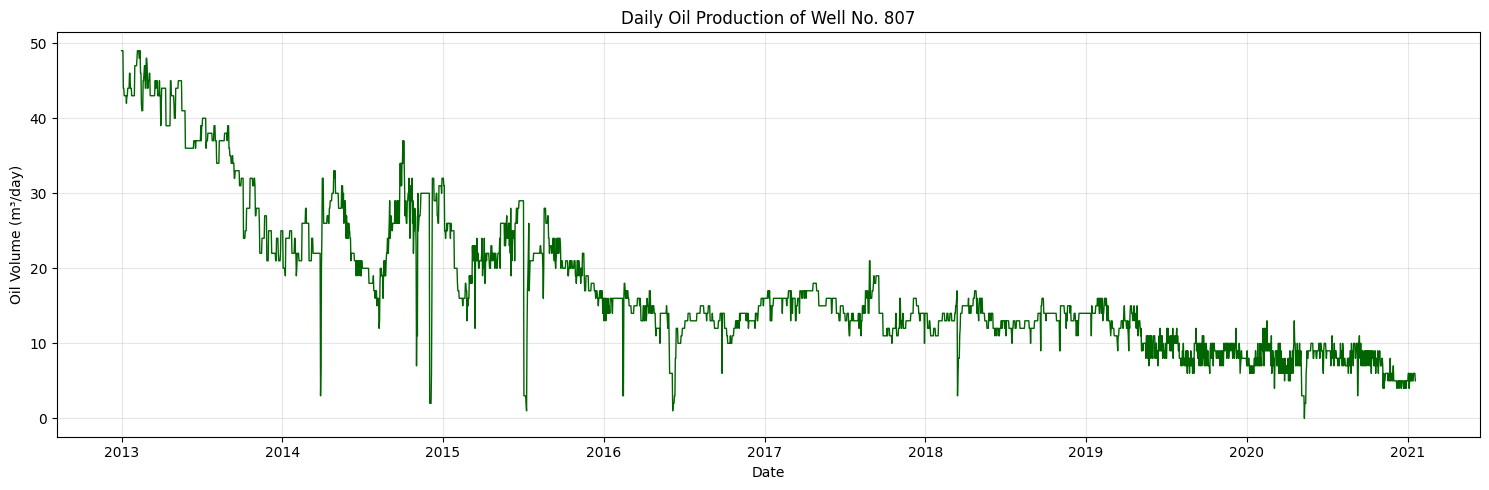

In [9]:
# ============================================================
# Cell 9 - Visualize Daily Oil Production
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    df["date"],
    df["oil_volume"],
    color="darkgreen",
    linewidth=1
)

plt.title("Daily Oil Production of Well No. 807")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Cell 10 - Chronological Train-Test Split
# ============================================================

TRAIN_RATIO = 0.80

split_index = int(len(df) * TRAIN_RATIO)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Total observations:", len(df))
print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print("\nTraining period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

Total observations: 2940
Training observations: 2352
Testing observations: 588

Training period:
2013-01-01 00:00:00 to 2019-06-10 00:00:00

Testing period:
2019-06-11 00:00:00 to 2021-01-18 00:00:00


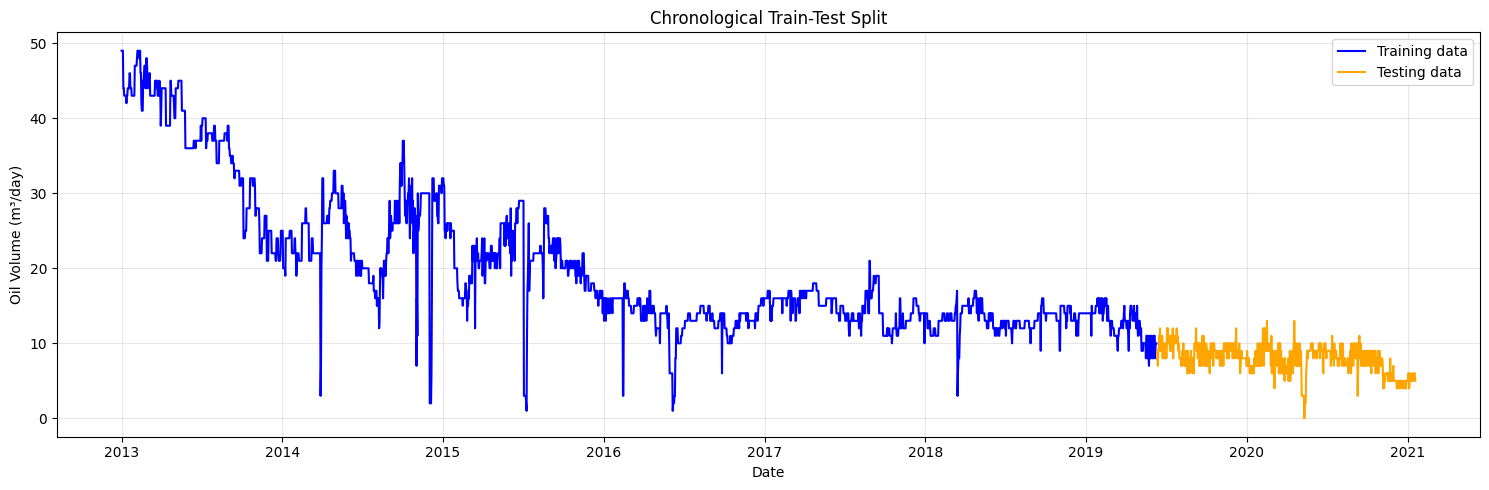

In [11]:
# ============================================================
# Cell 11 - Visualize Train-Test Split
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    train_df["date"],
    train_df["oil_volume"],
    label="Training data",
    color="blue"
)

plt.plot(
    test_df["date"],
    test_df["oil_volume"],
    label="Testing data",
    color="orange"
)

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Cell 12 - Scale Oil Production Values
# ============================================================

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler using training data only
scaler.fit(
    train_df[["oil_volume"]]
)

# Transform the complete dataset using the training scale
scaled_oil = scaler.transform(
    df[["oil_volume"]]
)

print("Original first five values:")
print(df["oil_volume"].head().to_numpy())

print("\nScaled first five values:")
print(scaled_oil[:5].flatten())

print("\nScaled data shape:", scaled_oil.shape)

Original first five values:
[49. 49. 49. 49. 44.]

Scaled first five values:
[1.         1.         1.         1.         0.89583333]

Scaled data shape: (2940, 1)


In [13]:
# ============================================================
# Cell 13 - Create Sliding-Window Sequences
# ============================================================

LOOKBACK = 30


def create_sequences(data, lookback):
    """
    Convert time-series values into LSTM input sequences.

    Parameters
    ----------
    data:
        Scaled time-series values.

    lookback:
        Number of previous days used for prediction.

    Returns
    -------
    X:
        Input sequences.

    y:
        Target values.
    """

    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [14]:
# ============================================================
# Cell 14 - Prepare Training and Testing Sequences
# ============================================================

# Training portion of the scaled data
train_scaled = scaled_oil[:split_index]

# Include the final 30 training days as context for test data
test_scaled = scaled_oil[split_index - LOOKBACK:]


X_train, y_train = create_sequences(
    train_scaled,
    LOOKBACK
)

X_test, y_test = create_sequences(
    test_scaled,
    LOOKBACK
)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2322, 30, 1)
y_train shape: (2322, 1)

X_test shape: (588, 30, 1)
y_test shape: (588, 1)


In [15]:
# ============================================================
# Cell 15 - Examine One Training Sequence
# ============================================================

print("Shape of one input sequence:", X_train[0].shape)

print("\nFirst input sequence:")
print(X_train[0].flatten())

print("\nTarget value:")
print(y_train[0][0])

print("\nOriginal target value:")
print(
    scaler.inverse_transform(
        y_train[0].reshape(1, -1)
    )[0, 0]
)

Shape of one input sequence: (30, 1)

First input sequence:
[1.         1.         1.         1.         0.89583333 0.89583333
 0.875      0.875      0.875      0.875      0.875      0.85416667
 0.875      0.875      0.89583333 0.89583333 0.89583333 0.89583333
 0.9375     0.9375     0.89583333 0.89583333 0.89583333 0.875
 0.875      0.875      0.875      0.875      0.875      0.875     ]

Target value:
0.9583333333333333

Original target value:
47.0


In [16]:
# ============================================================
# Cell 16 - Build the LSTM Model
# ============================================================

model = Sequential([
    Input(shape=(LOOKBACK, 1)),

    LSTM(
        units=32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(
        units=16,
        activation="relu"
    ),

    Dense(units=1)
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================================
# Cell 17 - Configure Early Stopping
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [18]:
# ============================================================
# Cell 18 - Train the Model
# ============================================================

history = model.fit(
    X_train,
    y_train,

    epochs=50,
    batch_size=32,

    validation_split=0.10,

    shuffle=False,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0751 - mean_absolute_error: 0.1690 - val_loss: 8.2356e-04 - val_mean_absolute_error: 0.0213
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0126 - mean_absolute_error: 0.0735 - val_loss: 8.4554e-04 - val_mean_absolute_error: 0.0223
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0116 - mean_absolute_error: 0.0702 - val_loss: 7.9553e-04 - val_mean_absolute_error: 0.0219
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0092 - mean_absolute_error: 0.0631 - val_loss: 7.5671e-04 - val_mean_absolute_error: 0.0212
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0074 - mean_absolute_error: 0.0563 - val_loss: 7.4739e-04 - val_mean_absolute_error: 0.0218
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0060 - mean_absolute_error: 0.0499 - val_loss: 7.1083e-04 - val_mean_absolute_error: 0.0212
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - mean_absolute_erro

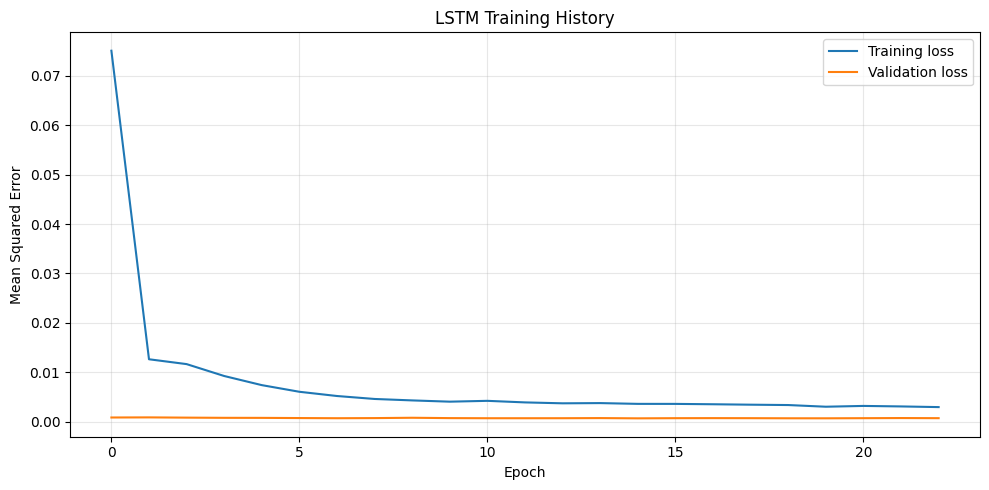

In [19]:
# ============================================================
# Cell 19 - Plot Training and Validation Loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Cell 20 - Make Predictions
# ============================================================

scaled_predictions = model.predict(
    X_test,
    verbose=0
)

# Convert predictions back to m³/day
predictions = scaler.inverse_transform(
    scaled_predictions
).flatten()

actual_values = scaler.inverse_transform(
    y_test
).flatten()

test_dates = (
    df["date"]
    .iloc[split_index:]
    .reset_index(drop=True)
)


print("Number of predictions:", len(predictions))
print("Number of actual values:", len(actual_values))

comparison_df = pd.DataFrame({
    "date": test_dates,
    "actual_oil_volume": actual_values,
    "predicted_oil_volume": predictions
})

display(comparison_df.head(10))

Number of predictions: 588
Number of actual values: 588


,date,actual_oil_volume,predicted_oil_volume
0,2019-06-11,8.0,10.787674
1,2019-06-12,9.0,10.455980
2,2019-06-13,7.0,10.347761
3,2019-06-14,9.0,9.925813
4,2019-06-15,9.0,9.919636
5,2019-06-16,11.0,9.932215
6,2019-06-17,9.0,10.296309
7,2019-06-18,12.0,10.269122
8,2019-06-19,9.0,10.756577
9,2019-06-20,9.0,10.648970


In [21]:
# ============================================================
# Cell 21 - Evaluate the LSTM Model
# ============================================================

mae = mean_absolute_error(
    actual_values,
    predictions
)

mse = mean_squared_error(
    actual_values,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    actual_values,
    predictions
)

# Avoid division by zero when calculating MAPE
non_zero_mask = actual_values != 0

mape = np.mean(
    np.abs(
        (
            actual_values[non_zero_mask]
            - predictions[non_zero_mask]
        )
        / actual_values[non_zero_mask]
    )
) * 100


print("LSTM evaluation results")
print("-----------------------")
print(f"MAE  : {mae:.2f} m³/day")
print(f"RMSE : {rmse:.2f} m³/day")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

LSTM evaluation results
-----------------------
MAE  : 1.61 m³/day
RMSE : 1.94 m³/day
R²   : -0.0503
MAPE : 24.84%


In [22]:
# ============================================================
# Cell 22 - Compare LSTM with Persistence Baseline
# ============================================================

# Last value from each 30-day input window
baseline_scaled = X_test[:, -1, :]

baseline_predictions = scaler.inverse_transform(
    baseline_scaled
).flatten()


baseline_mae = mean_absolute_error(
    actual_values,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    actual_values,
    baseline_predictions
)


results_df = pd.DataFrame({
    "Model": [
        "LSTM",
        "Persistence baseline"
    ],

    "MAE": [
        mae,
        baseline_mae
    ],

    "RMSE": [
        rmse,
        baseline_rmse
    ],

    "R2": [
        r2,
        baseline_r2
    ]
})

display(results_df.round(4))

,Model,MAE,RMSE,R2
0,LSTM,1.6074,1.9399,-0.0503
1,Persistence baseline,1.2092,1.6858,0.2069


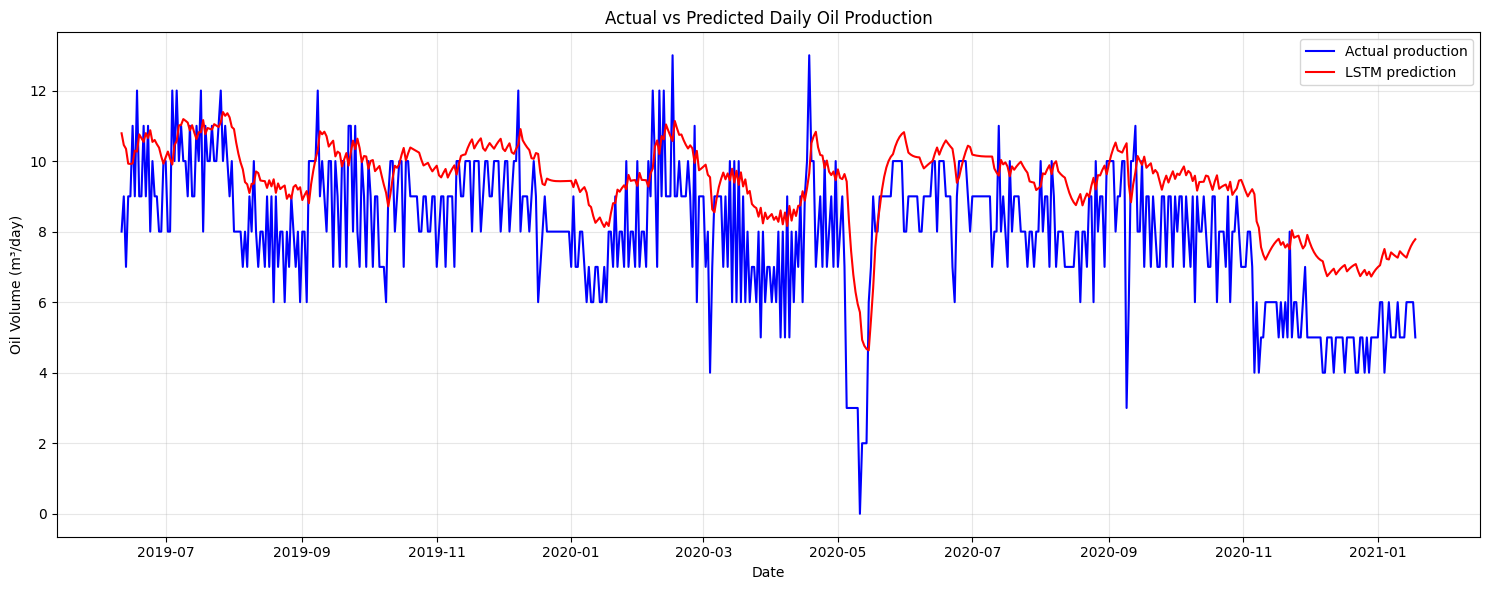

In [23]:
# ============================================================
# Cell 23 - Plot Actual and Predicted Values
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    actual_values,
    label="Actual production",
    color="blue",
    linewidth=1.5
)

plt.plot(
    test_dates,
    predictions,
    label="LSTM prediction",
    color="red",
    linewidth=1.5
)

plt.title("Actual vs Predicted Daily Oil Production")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

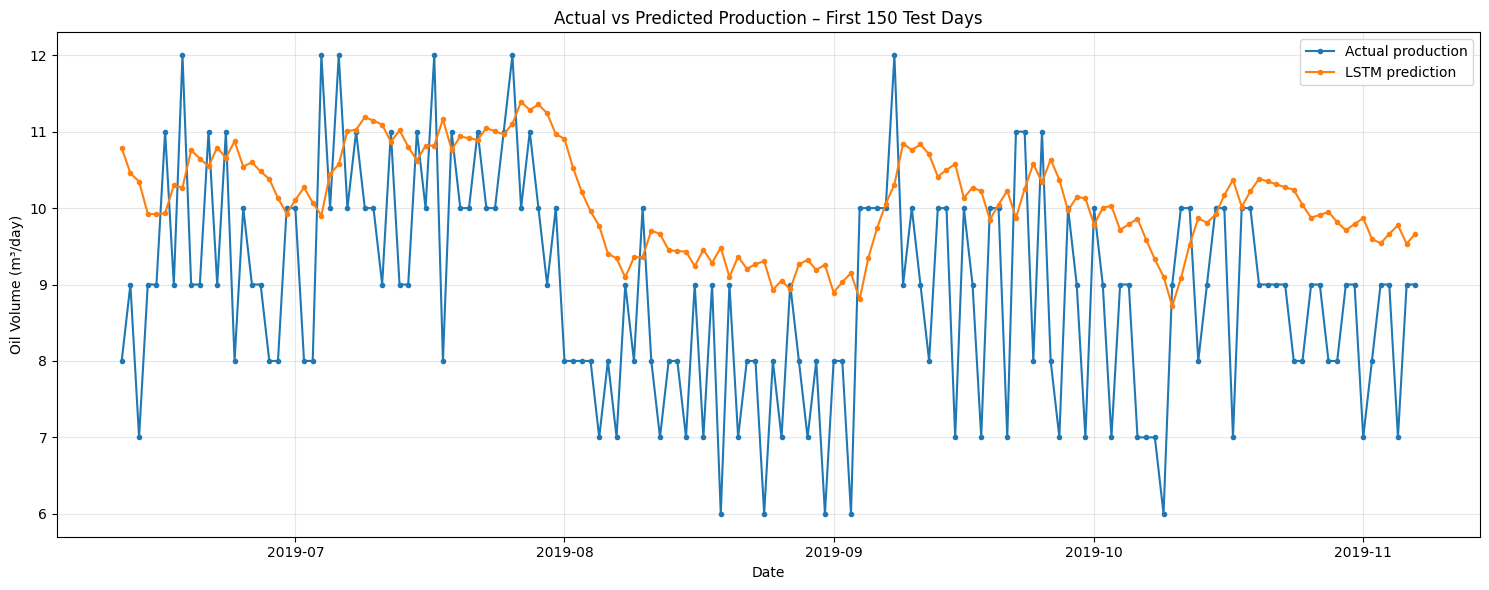

In [24]:
# ============================================================
# Cell 24 - Plot First 150 Test Predictions
# ============================================================

DISPLAY_DAYS = 150

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates[:DISPLAY_DAYS],
    actual_values[:DISPLAY_DAYS],
    label="Actual production",
    marker="o",
    markersize=3
)

plt.plot(
    test_dates[:DISPLAY_DAYS],
    predictions[:DISPLAY_DAYS],
    label="LSTM prediction",
    marker="o",
    markersize=3
)

plt.title(
    f"Actual vs Predicted Production – First {DISPLAY_DAYS} Test Days"
)

plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# Cell 25 - Predict Next Day's Oil Production
# ============================================================

# Select the most recent 30 scaled observations
last_sequence = scaled_oil[-LOOKBACK:]

# Add the sample dimension
last_sequence = last_sequence.reshape(
    1,
    LOOKBACK,
    1
)

# Predict the next scaled value
next_day_scaled = model.predict(
    last_sequence,
    verbose=0
)

# Convert prediction back to m³/day
next_day_prediction = scaler.inverse_transform(
    next_day_scaled
)[0, 0]

last_date = df["date"].max()
next_date = last_date + pd.Timedelta(days=1)


print("Last date in dataset:", last_date.date())
print("Forecast date:", next_date.date())

print(
    f"Predicted oil production: "
    f"{next_day_prediction:.2f} m³/day"
)

Last date in dataset: 2021-01-18
Forecast date: 2021-01-19
Predicted oil production: 7.63 m³/day


In [26]:
# ============================================================
# Cell 26 - Forecast the Next 30 Days
# ============================================================

FORECAST_DAYS = 30

# Copy the latest 30 observations
current_sequence = scaled_oil[-LOOKBACK:].copy()

future_scaled_predictions = []


for _ in range(FORECAST_DAYS):

    # Shape required by the LSTM:
    # (samples, time steps, features)
    model_input = current_sequence.reshape(
        1,
        LOOKBACK,
        1
    )

    next_scaled_value = model.predict(
        model_input,
        verbose=0
    )[0, 0]

    future_scaled_predictions.append(
        next_scaled_value
    )

    # Remove the oldest value and append the prediction
    current_sequence = np.vstack([
        current_sequence[1:],
        [[next_scaled_value]]
    ])


future_predictions = scaler.inverse_transform(
    np.array(future_scaled_predictions).reshape(-1, 1)
).flatten()


future_dates = pd.date_range(
    start=df["date"].max() + pd.Timedelta(days=1),
    periods=FORECAST_DAYS,
    freq="D"
)


future_df = pd.DataFrame({
    "date": future_dates,
    "predicted_oil_volume": future_predictions
})

display(future_df)

,date,predicted_oil_volume
0,2021-01-19,7.627644
1,2021-01-20,8.068754
2,2021-01-21,8.518482
3,2021-01-22,8.927116
4,2021-01-23,9.281293
5,2021-01-24,9.615900
6,2021-01-25,9.928007
7,2021-01-26,10.216108
8,2021-01-27,10.487532
9,2021-01-28,10.736219


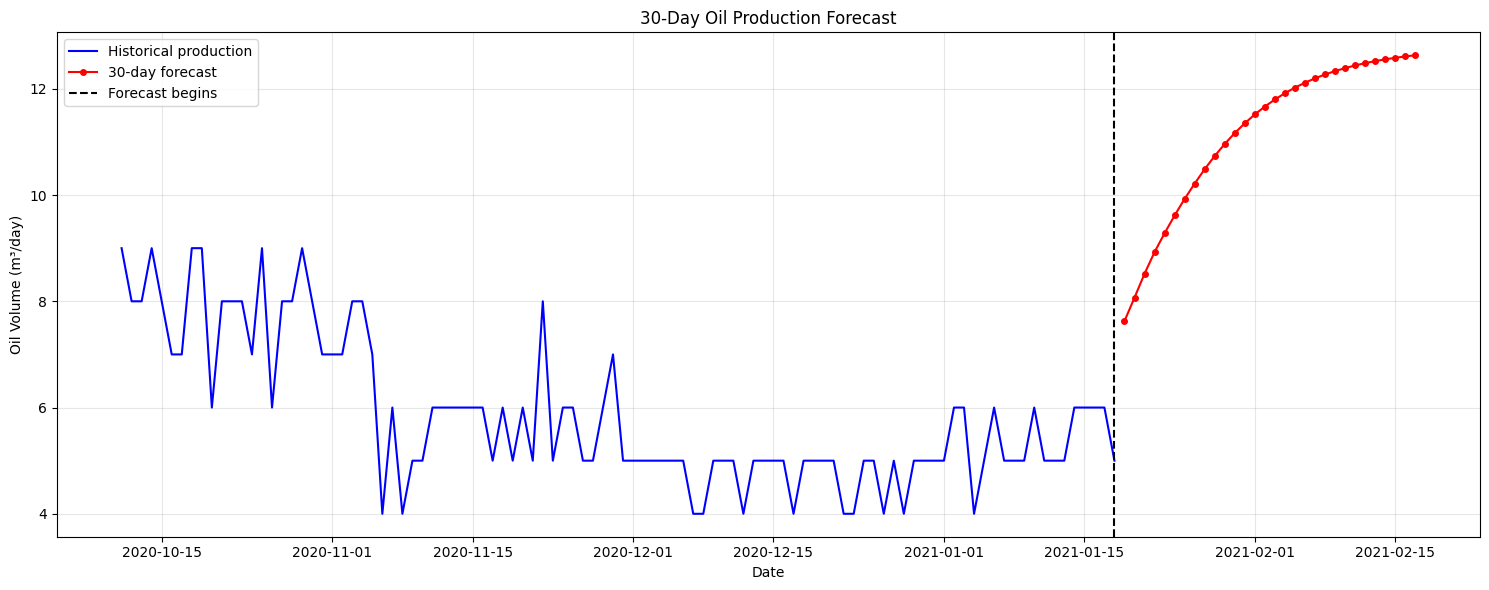

In [27]:
# ============================================================
# Cell 27 - Plot Future Oil Production Forecast
# ============================================================

HISTORY_DAYS = 100

recent_history = df.tail(HISTORY_DAYS)


plt.figure(figsize=(15, 6))

plt.plot(
    recent_history["date"],
    recent_history["oil_volume"],
    label="Historical production",
    color="blue"
)

plt.plot(
    future_df["date"],
    future_df["predicted_oil_volume"],
    label="30-day forecast",
    color="red",
    marker="o",
    markersize=4
)

plt.axvline(
    x=df["date"].max(),
    color="black",
    linestyle="--",
    label="Forecast begins"
)

plt.title("30-Day Oil Production Forecast")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# Cell 28 - Save and Download Model
# ============================================================

import joblib
from google.colab import files


MODEL_PATH = "oil_production_lstm.keras"
SCALER_PATH = "oil_production_scaler.pkl"


model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)


print("Model saved:", MODEL_PATH)
print("Scaler saved:", SCALER_PATH)


files.download(MODEL_PATH)
files.download(SCALER_PATH)

Model saved: oil_production_lstm.keras
Scaler saved: oil_production_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>